# TPU (Trade Policy Uncertainty) Descriptive Analysis

This notebook provides comprehensive descriptive statistics and visualizations for Trade Policy Uncertainty (TPU) data analysis.

**Data Sources:**
- `TPU_full_data.csv`: Full article-level data (2006-2025)
- `TPU_country_level.csv`: Country × Month aggregated TPU indices
- `TPU_agg_income_group.csv`: Aggregated by income group (LIC, EM, AE, AM)
- `TPU_agg_un_region.csv`: Aggregated by UN region (5 regions)
- `TPU_agg_imf_dept.csv`: Aggregated by IMF department (5 depts)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Figure size defaults
SINGLE_FIG_SIZE = (12, 6)
MULTI_FIG_SIZE = (14, 10)

# Data paths
DATA_DIR = '/data/home/xiong/data/Fund/Factiva_News/results/merged_results/'
OUTPUT_DIR = '/data/home/xiong/data/Fund/Factiva_News/results/merged_results/figures/'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
# Load all datasets
print("Loading datasets...")

# Country-level TPU data
df_country = pd.read_csv(f'{DATA_DIR}TPU_country_level.csv')
df_country['pub_period'] = pd.to_datetime(df_country['pub_period'])

# Aggregated data by income group
df_income = pd.read_csv(f'{DATA_DIR}TPU_agg_income_group.csv')
df_income['pub_period'] = pd.to_datetime(df_income['pub_period'])

# Aggregated data by UN region
df_region = pd.read_csv(f'{DATA_DIR}TPU_agg_un_region.csv')
df_region['pub_period'] = pd.to_datetime(df_region['pub_period'])

# Aggregated data by IMF department
df_imf = pd.read_csv(f'{DATA_DIR}TPU_agg_imf_dept.csv')
df_imf['pub_period'] = pd.to_datetime(df_imf['pub_period'])

# Full article-level data (for sample statistics only - large file)
# We'll load just the necessary columns to save memory
print("Loading full data (this may take a moment)...")
df_full = pd.read_csv(f'{DATA_DIR}TPU_full_data.csv', 
                      usecols=['id', 'language_code', 'ILA_TPU_Flag', 
                               'iso', 'country_name', 'pub_period'])
df_full['pub_period'] = pd.to_datetime(df_full['pub_period'])

print(f"Loaded {len(df_country):,} country-period records")
print(f"Loaded {len(df_full):,} article records")

Loading datasets...
Loading full data (this may take a moment)...
Loaded 39,606 country-period records
Loaded 19,032,358 article records


---
## Section 1: Data Overview & Sample Statistics

**Goal**: Provide overall statistics on the full data sample

### 1.1 Dataset Summary

In [3]:
# Total articles, date range, unique countries
total_articles = len(df_full)
date_min = df_full['pub_period'].min()
date_max = df_full['pub_period'].max()
unique_countries = df_full['iso'].dropna().nunique()

# TPU vs non-TPU article counts
tpu_articles = df_full['ILA_TPU_Flag'].sum()
non_tpu_articles = total_articles - tpu_articles
tpu_pct = (tpu_articles / total_articles) * 100

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total Articles:        {total_articles:,}")
print(f"Date Range:            {date_min.strftime('%Y-%m')} to {date_max.strftime('%Y-%m')}")
print(f"Unique Countries:      {unique_countries}")
print(f"\nTPU Articles:          {tpu_articles:,} ({tpu_pct:.2f}%)")
print(f"Non-TPU Articles:      {non_tpu_articles:,} ({100-tpu_pct:.2f}%)")
print("=" * 60)

DATASET SUMMARY
Total Articles:        19,032,358
Date Range:            2006-01 to 2025-04
Unique Countries:      220

TPU Articles:          375,906 (1.98%)
Non-TPU Articles:      18,656,452 (98.02%)


### 1.2 Temporal Distribution

Chart: Monthly Article Count Over Time (2006-2025)


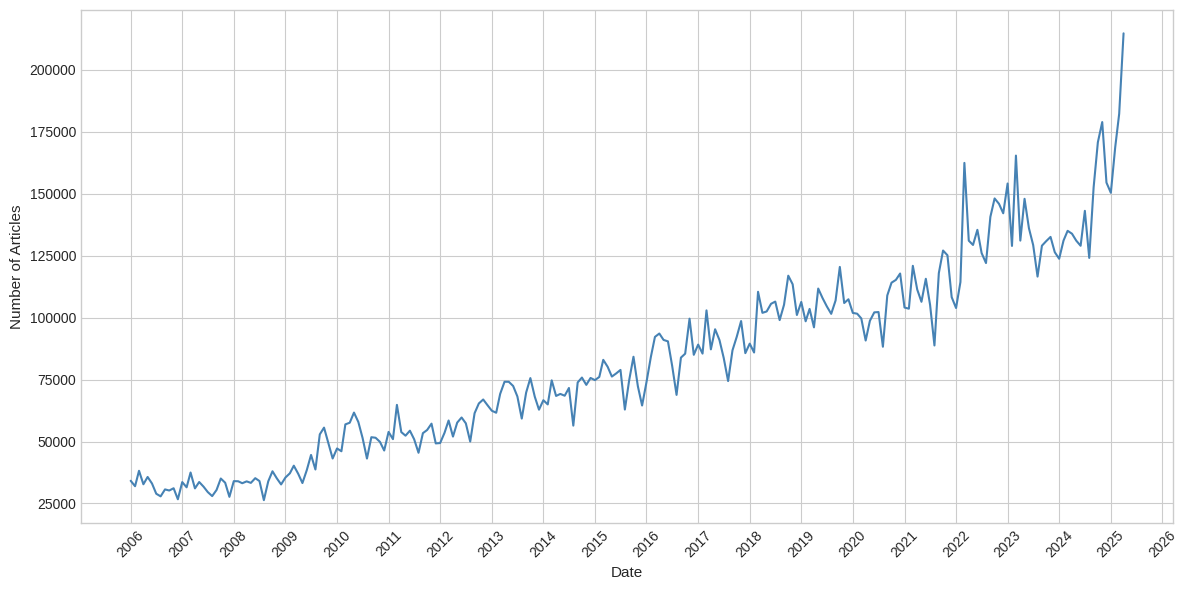

In [4]:
# Line plot: Number of articles over time (monthly)
monthly_counts = df_full.groupby('pub_period').size().reset_index(name='article_count')

print("Chart: Monthly Article Count Over Time (2006-2025)")

fig, ax = plt.subplots(figsize=SINGLE_FIG_SIZE)
ax.plot(monthly_counts['pub_period'], monthly_counts['article_count'], 
        linewidth=1.5, color='steelblue')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Number of Articles', fontsize=11)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}temporal_distribution_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Language Distribution

Chart: Article Distribution by Language


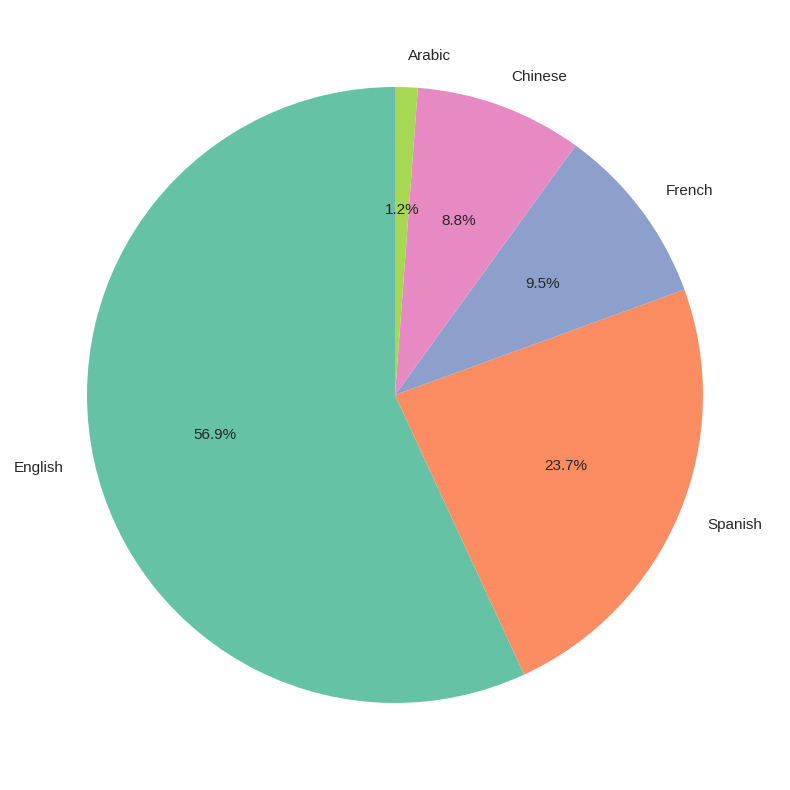


Language Distribution:
  English: 10,827,393 (56.9%)
  Spanish: 4,505,467 (23.7%)
  French: 1,801,786 (9.5%)
  Chinese: 1,672,462 (8.8%)
  Arabic: 225,250 (1.2%)


In [5]:
# Language distribution
lang_counts = df_full['language_code'].value_counts()

# Map language codes to full names
lang_map = {'en': 'English', 'es': 'Spanish', 'fr': 'French', 'zhcn': 'Chinese', 'ar': 'Arabic'}
lang_counts.index = lang_counts.index.map(lambda x: lang_map.get(x, x))

print("Chart: Article Distribution by Language")

# Pie chart: Share by language
fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette('Set2', n_colors=len(lang_counts))
wedges, texts, autotexts = ax.pie(lang_counts.values, labels=lang_counts.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90,
                                   textprops={'fontsize': 11})
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}language_distribution_pie.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLanguage Distribution:")
for lang, count in lang_counts.items():
    print(f"  {lang}: {count:,} ({count/total_articles*100:.1f}%)")

Chart: Language Mix Over Time


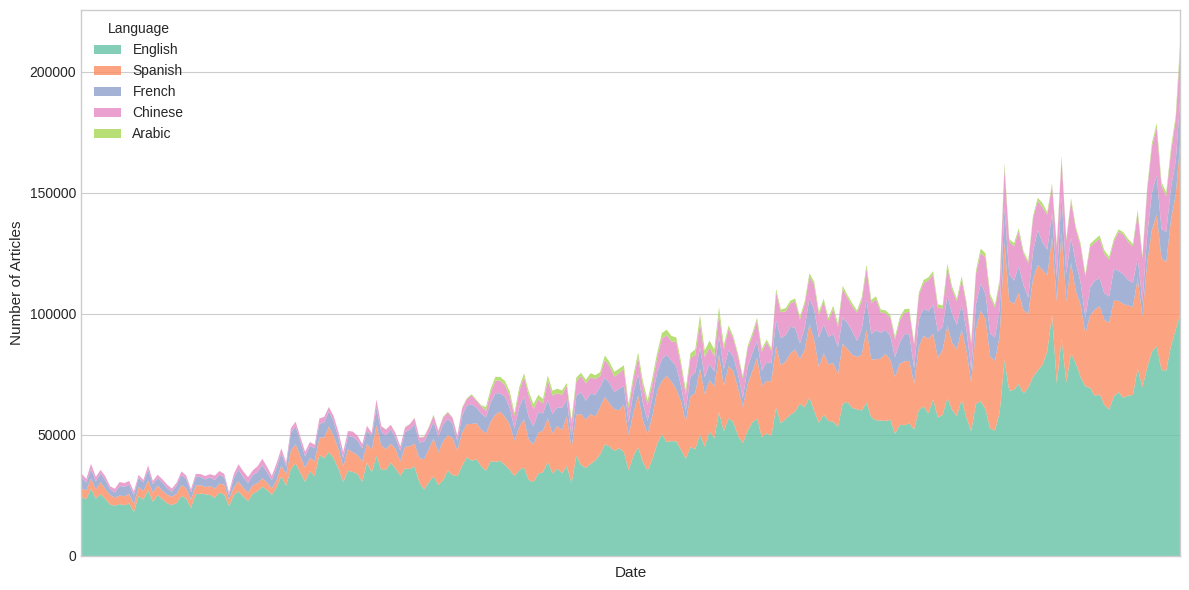

In [6]:
# Stacked area chart: Language mix over time
lang_time = df_full.groupby(['pub_period', 'language_code']).size().unstack(fill_value=0)

# Keep top 5 languages
top_langs = lang_counts.head(5).index.tolist()
lang_map_rev = {v: k for k, v in lang_map.items()}
top_lang_codes = [lang_map_rev.get(l, l) for l in top_langs]

# Filter and rename columns
lang_time_filtered = lang_time[[c for c in top_lang_codes if c in lang_time.columns]]
lang_time_filtered.columns = [lang_map.get(c, c) for c in lang_time_filtered.columns]

print("Chart: Language Mix Over Time")

fig, ax = plt.subplots(figsize=SINGLE_FIG_SIZE)
lang_time_filtered.plot.area(ax=ax, stacked=True, alpha=0.8, linewidth=0)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Number of Articles', fontsize=11)
ax.legend(title='Language', loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}language_distribution_time.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Geographic Coverage

Chart: Top 20 Countries by Article Count


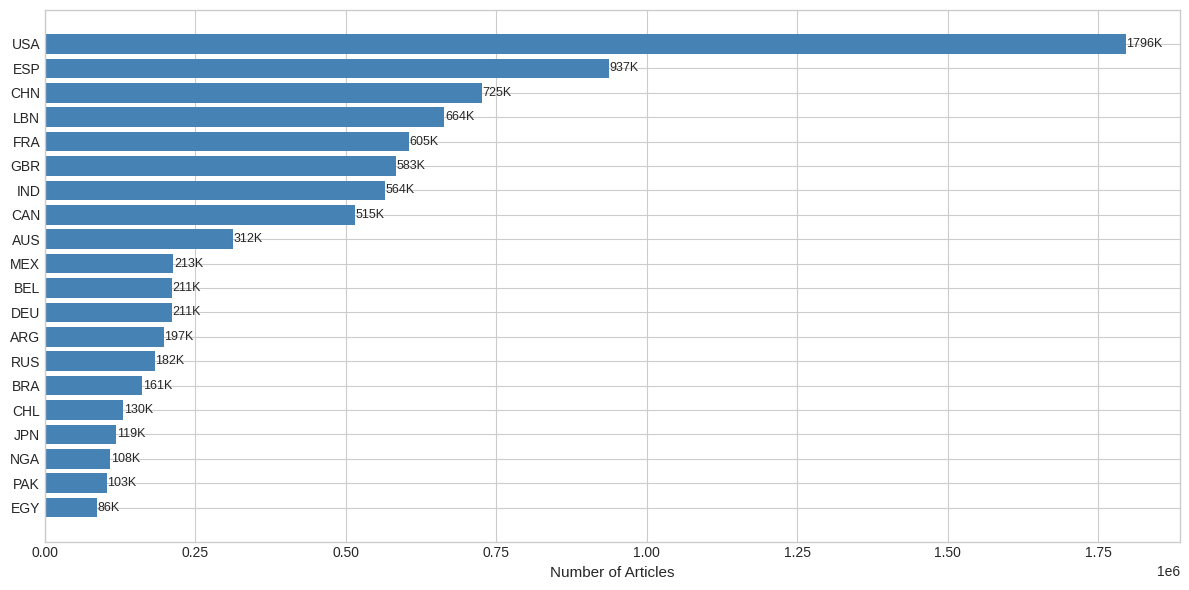

In [7]:
country_counts = df_full.groupby('iso').size().sort_values(ascending=False).head(20)

print("Chart: Top 20 Countries by Article Count")

fig, ax = plt.subplots(figsize=SINGLE_FIG_SIZE)
bars = ax.barh(range(len(country_counts)), country_counts.values, color='steelblue')
ax.set_yticks(range(len(country_counts)))
ax.set_yticklabels(country_counts.index)
ax.invert_yaxis()
ax.set_xlabel('Number of Articles', fontsize=11)

for i, (bar, val) in enumerate(zip(bars, country_counts.values)):
    ax.text(val + 1000, i, f'{val/1000:.0f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}geographic_coverage_top20.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Table: Coverage by UN region and income group
region_coverage = df_country.groupby('un_major_region').agg({
    'iso': 'nunique',
    'NUMBER_ARTICLES': 'sum',
    'TPUD_ARTICLES': 'sum'
}).rename(columns={'iso': 'Countries', 'NUMBER_ARTICLES': 'Total Articles', 'TPUD_ARTICLES': 'TPU Articles'})
region_coverage['TPU Rate (%)'] = (region_coverage['TPU Articles'] / region_coverage['Total Articles'] * 100).round(2)

print("\nCoverage by UN Region:")
print(region_coverage.to_string())

income_coverage = df_country.groupby('income_group').agg({
    'iso': 'nunique',
    'NUMBER_ARTICLES': 'sum',
    'TPUD_ARTICLES': 'sum'
}).rename(columns={'iso': 'Countries', 'NUMBER_ARTICLES': 'Total Articles', 'TPUD_ARTICLES': 'TPU Articles'})
income_coverage['TPU Rate (%)'] = (income_coverage['TPU Articles'] / income_coverage['Total Articles'] * 100).round(2)

print("\n\nCoverage by Income Group:")
print(income_coverage.to_string())


Coverage by UN Region:
                 Countries  Total Articles  TPU Articles  TPU Rate (%)
un_major_region                                                       
Africa                  51          464021          8917          1.92
Americas                34         3385655         97549          2.88
Asia                    45         3054049        160082          5.24
Europe                  41         3413641         58850          1.72
Oceania                 14          341596         16655          4.88


Coverage by Income Group:
              Countries  Total Articles  TPU Articles  TPU Rate (%)
income_group                                                       
AE                   38         6006739        143916           2.4
EM                   91         4170225        183683           4.4
LIC                  56          481998         14454           3.0


---
## Section 2: Global TPU Trend

**Goal**: High-level view of global TPU trend over time

### 2.1 Global TPU Index Time Series

In [9]:
# Calculate global TPU index (simple average and GDP-weighted)
global_simple = df_country.groupby('pub_period').agg({
    'TPUD_index': 'mean',
    'NUMBER_ARTICLES': 'sum',
    'TPUD_ARTICLES': 'sum'
}).reset_index()
global_simple['global_tpu'] = (global_simple['TPUD_ARTICLES'] / global_simple['NUMBER_ARTICLES']) * 100

# GDP-weighted average
df_country_gdp = df_country.dropna(subset=['NGDP_USD_2024'])
global_gdp_weighted = df_country_gdp.groupby('pub_period').apply(
    lambda x: np.average(x['TPUD_index'], weights=x['NGDP_USD_2024']) 
              if x['NGDP_USD_2024'].sum() > 0 else np.nan
).reset_index(name='gdp_weighted_tpu')

# Create normalized series (base 100 = first period)
global_simple['global_tpu_normalized'] = (global_simple['global_tpu'] / global_simple['global_tpu'].iloc[0] * 100).round(2)
global_gdp_weighted['gdp_weighted_tpu_normalized'] = (global_gdp_weighted['gdp_weighted_tpu'] / global_gdp_weighted['gdp_weighted_tpu'].iloc[0] * 100).round(2)


In [10]:
global_simple

,pub_period,TPUD_index,NUMBER_ARTICLES,TPUD_ARTICLES,global_tpu,global_tpu_normalized
0,2006-01-01,2.468580,19519,363,1.859726,100.00
1,2006-02-01,2.298160,18714,391,2.089345,112.35
2,2006-03-01,2.302089,22697,648,2.855003,153.52
3,2006-04-01,2.210915,19777,528,2.669768,143.56
4,2006-05-01,1.959030,21886,409,1.868775,100.49
...,...,...,...,...,...,...
227,2024-12-01,2.641080,82530,3174,3.845874,206.80
228,2025-01-01,2.641582,83947,4705,5.604727,301.37
229,2025-02-01,4.627039,98850,9881,9.995953,537.50
230,2025-03-01,4.507039,107336,11424,10.643214,572.30


Chart: Global TPU Index Over Time (2006-2025)


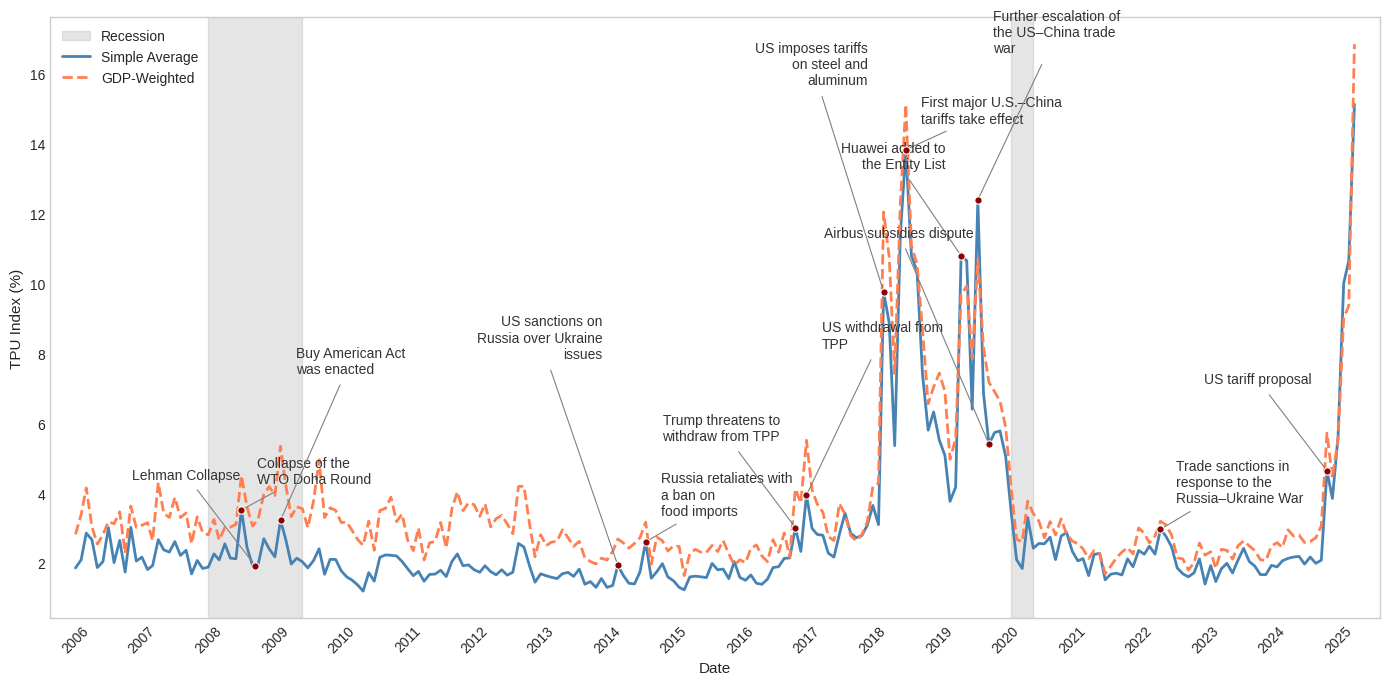

In [27]:
# Plot global TPU with recession shading and key events
print("Chart: Global TPU Index Over Time (2006-2025)")

fig, ax = plt.subplots(figsize=(14, 7))

# Recession shading
ax.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2009-06-01'), 
           alpha=0.2, color='gray', label='Recession')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'), 
           alpha=0.2, color='gray')

# Plot simple average and GDP-weighted
ax.plot(global_simple['pub_period'], global_simple['global_tpu'], 
        label='Simple Average', linewidth=2, color='steelblue')
ax.plot(global_gdp_weighted['pub_period'], global_gdp_weighted['gdp_weighted_tpu'], 
        label='GDP-Weighted', linewidth=2, color='coral', linestyle='--')

# Key trade events: (date, label). Resolve y-value from simple average series.
events_raw = [
    ('2008-07-01', 'Collapse of the WTO Doha Round'),
    ('2008-09-15', 'Lehman Collapse'),
    ('2009-02-01', 'Buy American Act was enacted'),
    ('2014-03-01', 'US sanctions on Russia over Ukraine issues'),
    ('2014-08-01', 'Russia retaliates with a ban on food imports'),
    ('2016-11-01', 'Trump threatens to withdraw from TPP'),
    ('2017-01-01', 'US withdrawal from TPP'),
    ('2018-03-01', 'US imposes tariffs on steel and aluminum'),
    ('2018-07-01', 'First major U.S.–China tariffs take effect'),
    ('2019-05-01', 'Huawei added to the Entity List'),
    ('2019-08-01', 'Further escalation of the US–China trade war'),
    ('2019-10-01', 'Airbus subsidies dispute'),
    ('2022-05-01', 'Trade sanctions in response to the Russia–Ukraine War'),
    ('2024-11-01', 'US tariff proposal'),
]
tpu_series = global_simple.set_index('pub_period')['global_tpu']
events = []
for date_str, label in events_raw:
    dt = pd.Timestamp(date_str)
    period = dt.to_period('M')
    match = global_simple[global_simple['pub_period'].dt.to_period('M') == period]
    if len(match) > 0:
        y_val = match['global_tpu'].iloc[0]
    else:
        nearest = tpu_series.reindex([dt], method='nearest')
        y_val = nearest.iloc[0] if not nearest.isna().all() else tpu_series.iloc[0]
    events.append((dt, label, y_val))

# Point markers and callout annotations (no vertical lines)
# Four vertical tiers + wrapped text so labels are short and well spread
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
label_tiers = [0.04, 0.14, 0.24, 0.34]  # fractions of y_range above point
max_words_per_line = 3
offset_x = pd.Timedelta(days=85)  # horizontal offset for left/right placement

def wrap_by_words(text, max_words=max_words_per_line):
    words = text.split()
    lines = [' '.join(words[i:i + max_words]) for i in range(0, len(words), max_words)]
    return '\n'.join(lines)

for i, (date, label, y_val) in enumerate(events):
    ax.scatter(date, y_val, s=28, color='darkred', zorder=5, edgecolors='white', linewidths=0.8)
    wrapped_label = wrap_by_words(label)
    tier_frac = label_tiers[i % len(label_tiers)]
    text_y = y_val + tier_frac * y_range
    if i % 2 == 0:
        text_x = date + offset_x
        ha = 'left'
    else:
        text_x = date - offset_x
        ha = 'right'
    ax.annotate(
        wrapped_label,
        xy=(date, y_val),
        xytext=(text_x, text_y),
        fontsize=10,
        color='#333',
        ha=ha,
        va='bottom',
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, shrinkA=5, shrinkB=2, connectionstyle='arc3,rad=0'),
    )

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('TPU Index (%)', fontsize=11)
ax.grid(False)
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.margins(x=0.02)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}global_tpu_trend.png', dpi=150, bbox_inches='tight')
plt.show()

Chart: Global TPU Index Over Time (2006-2025) — Normalized


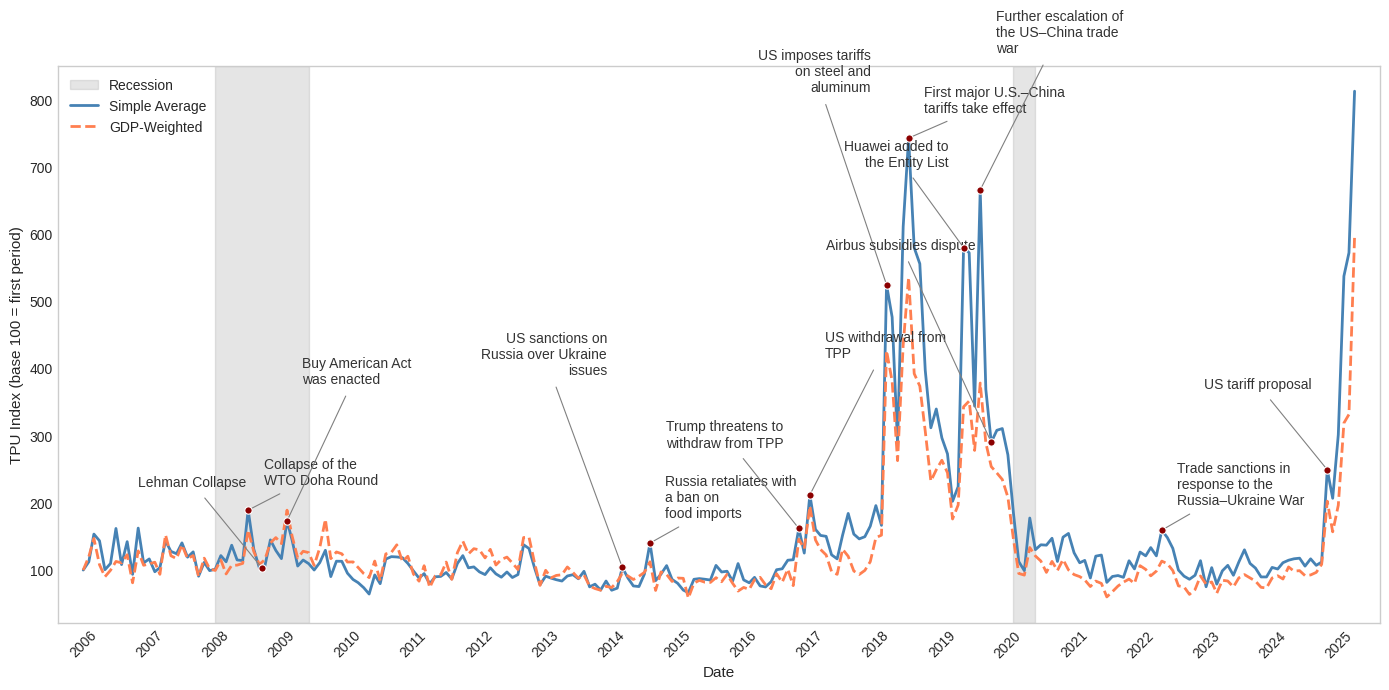

In [28]:
# Same chart with pre-calculated normalized series (base 100 = first period)
print("Chart: Global TPU Index Over Time (2006-2025) — Normalized")

fig, ax = plt.subplots(figsize=(14, 7))

# Recession shading
ax.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2009-06-01'),
           alpha=0.2, color='gray', label='Recession')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'),
           alpha=0.2, color='gray')

# Plot pre-calculated normalized simple average and GDP-weighted
ax.plot(global_simple['pub_period'], global_simple['global_tpu_normalized'],
        label='Simple Average', linewidth=2, color='steelblue')
ax.plot(global_gdp_weighted['pub_period'], global_gdp_weighted['gdp_weighted_tpu_normalized'],
        label='GDP-Weighted', linewidth=2, color='coral', linestyle='--')

# Same event list and callout styling as main TPU chart (y-values from normalized series)
events_raw = [
    ('2008-07-01', 'Collapse of the WTO Doha Round'),
    ('2008-09-15', 'Lehman Collapse'),
    ('2009-02-01', 'Buy American Act was enacted'),
    ('2014-03-01', 'US sanctions on Russia over Ukraine issues'),
    ('2014-08-01', 'Russia retaliates with a ban on food imports'),
    ('2016-11-01', 'Trump threatens to withdraw from TPP'),
    ('2017-01-01', 'US withdrawal from TPP'),
    ('2018-03-01', 'US imposes tariffs on steel and aluminum'),
    ('2018-07-01', 'First major U.S.–China tariffs take effect'),
    ('2019-05-01', 'Huawei added to the Entity List'),
    ('2019-08-01', 'Further escalation of the US–China trade war'),
    ('2019-10-01', 'Airbus subsidies dispute'),
    ('2022-05-01', 'Trade sanctions in response to the Russia–Ukraine War'),
    ('2024-11-01', 'US tariff proposal'),
]
tpu_series = global_simple.set_index('pub_period')['global_tpu_normalized']
events = []
for date_str, label in events_raw:
    dt = pd.Timestamp(date_str)
    period = dt.to_period('M')
    match = global_simple[global_simple['pub_period'].dt.to_period('M') == period]
    if len(match) > 0:
        y_val = match['global_tpu_normalized'].iloc[0]
    else:
        nearest = tpu_series.reindex([dt], method='nearest')
        y_val = nearest.iloc[0] if not nearest.isna().all() else tpu_series.iloc[0]
    events.append((dt, label, y_val))

# Point markers and callout annotations (same styling as main chart)
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
label_tiers = [0.04, 0.14, 0.24, 0.34]
max_words_per_line = 3
offset_x = pd.Timedelta(days=85)

def wrap_by_words(text, max_words=max_words_per_line):
    words = text.split()
    lines = [' '.join(words[i:i + max_words]) for i in range(0, len(words), max_words)]
    return '\n'.join(lines)

for i, (date, label, y_val) in enumerate(events):
    ax.scatter(date, y_val, s=28, color='darkred', zorder=5, edgecolors='white', linewidths=0.8)
    wrapped_label = wrap_by_words(label)
    tier_frac = label_tiers[i % len(label_tiers)]
    text_y = y_val + tier_frac * y_range
    if i % 2 == 0:
        text_x = date + offset_x
        ha = 'left'
    else:
        text_x = date - offset_x
        ha = 'right'
    ax.annotate(
        wrapped_label,
        xy=(date, y_val),
        xytext=(text_x, text_y),
        fontsize=10,
        color='#333',
        ha=ha,
        va='bottom',
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, shrinkA=5, shrinkB=2, connectionstyle='arc3,rad=0'),
    )

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('TPU Index (base 100 = first period)', fontsize=11)
ax.grid(False)
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.margins(x=0.02)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}global_tpu_trend_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 TPU Volatility Analysis

Chart: Global TPU Index and TPU Volatility (12-Month Rolling Standard Deviation)


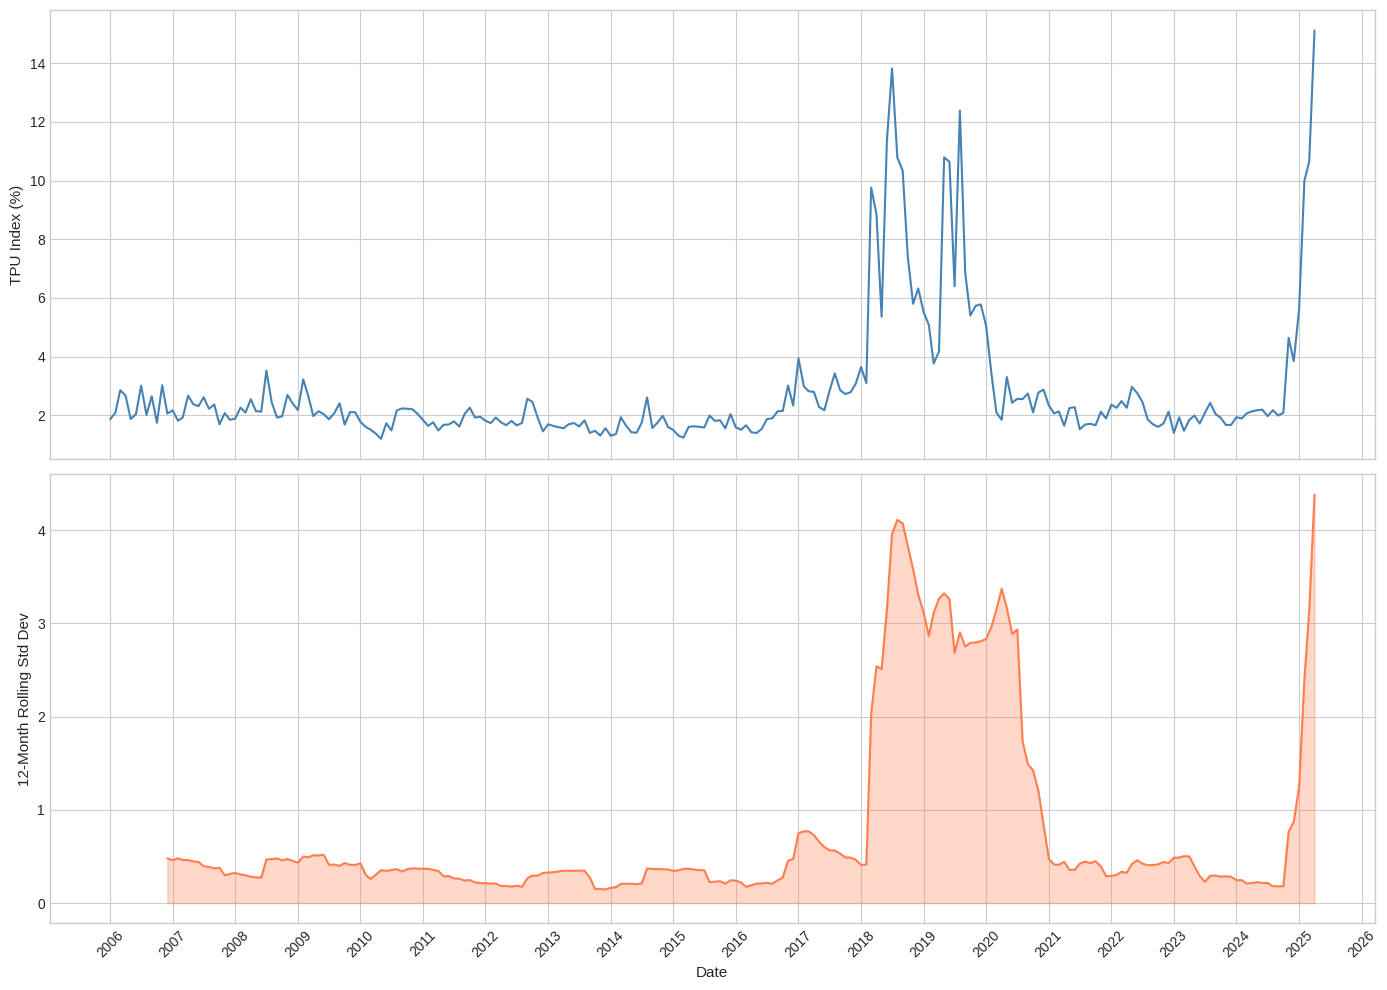


Periods of High Volatility (above 0.49):
    pub_period  global_tpu  rolling_std
37  2009-02-01    3.221674     0.498731
39  2009-04-01    1.970512     0.512001
40  2009-05-01    2.137436     0.512080
41  2009-06-01    2.035634     0.517533
132 2017-01-01    3.940700     0.749972
133 2017-02-01    2.986182     0.770268
134 2017-03-01    2.817969     0.769754
135 2017-04-01    2.792756     0.729737
136 2017-05-01    2.281719     0.659325
137 2017-06-01    2.168939     0.600180
138 2017-07-01    2.825589     0.566848
139 2017-08-01    3.426669     0.563455
140 2017-09-01    2.854552     0.530416
146 2018-03-01    9.757956     2.028242
147 2018-04-01    8.860097     2.540451
148 2018-05-01    5.356235     2.510898
149 2018-06-01   11.362831     3.151158
150 2018-07-01   13.817338     3.961292
151 2018-08-01   10.782612     4.110722
152 2018-09-01   10.337623     4.073321
153 2018-10-01    7.390310     3.829425
154 2018-11-01    5.797540     3.581099
155 2018-12-01    6.318094     3.30599

In [29]:
# Rolling 12-month standard deviation
global_simple_sorted = global_simple.sort_values('pub_period')
global_simple_sorted['rolling_std'] = global_simple_sorted['global_tpu'].rolling(window=12).std()

print("Chart: Global TPU Index and TPU Volatility (12-Month Rolling Standard Deviation)")

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# TPU Index
axes[0].plot(global_simple_sorted['pub_period'], global_simple_sorted['global_tpu'], 
             linewidth=1.5, color='steelblue')
axes[0].set_ylabel('TPU Index (%)', fontsize=11)

# Rolling volatility
axes[1].plot(global_simple_sorted['pub_period'], global_simple_sorted['rolling_std'], 
             linewidth=1.5, color='coral')
axes[1].fill_between(global_simple_sorted['pub_period'], 0, global_simple_sorted['rolling_std'],
                     alpha=0.3, color='coral')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('12-Month Rolling Std Dev', fontsize=11)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}tpu_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify periods of high uncertainty (above 75th percentile)
threshold = global_simple_sorted['rolling_std'].quantile(0.75)
high_vol = global_simple_sorted[global_simple_sorted['rolling_std'] > threshold]
print(f"\nPeriods of High Volatility (above {threshold:.2f}):")
print(high_vol[['pub_period', 'global_tpu', 'rolling_std']].to_string())

### 2.3 Year-over-Year Comparison

Chart: TPU Index Heatmap by Month and Year


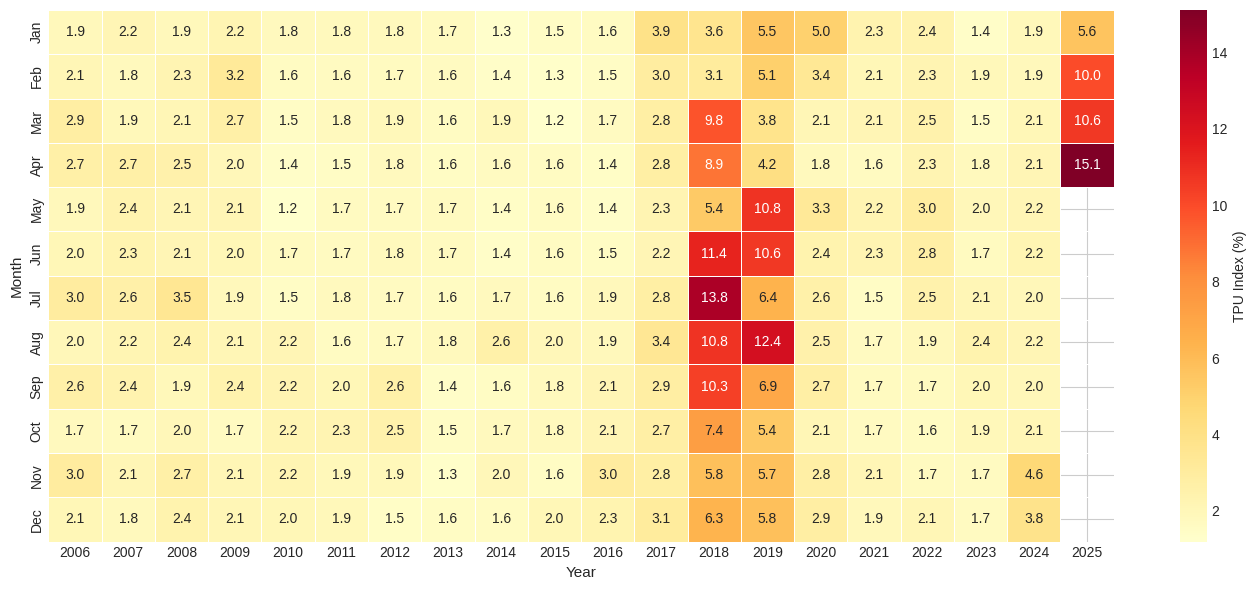

In [30]:
# Heatmap: TPU index by month and year
global_simple_sorted['year'] = global_simple_sorted['pub_period'].dt.year
global_simple_sorted['month'] = global_simple_sorted['pub_period'].dt.month

heatmap_data = global_simple_sorted.pivot_table(values='global_tpu', 
                                                 index='month', 
                                                 columns='year', 
                                                 aggfunc='mean')

print("Chart: TPU Index Heatmap by Month and Year")

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.1f', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'TPU Index (%)'})
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Month', fontsize=11)
ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}tpu_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Chart: Distribution of Monthly TPU by Year


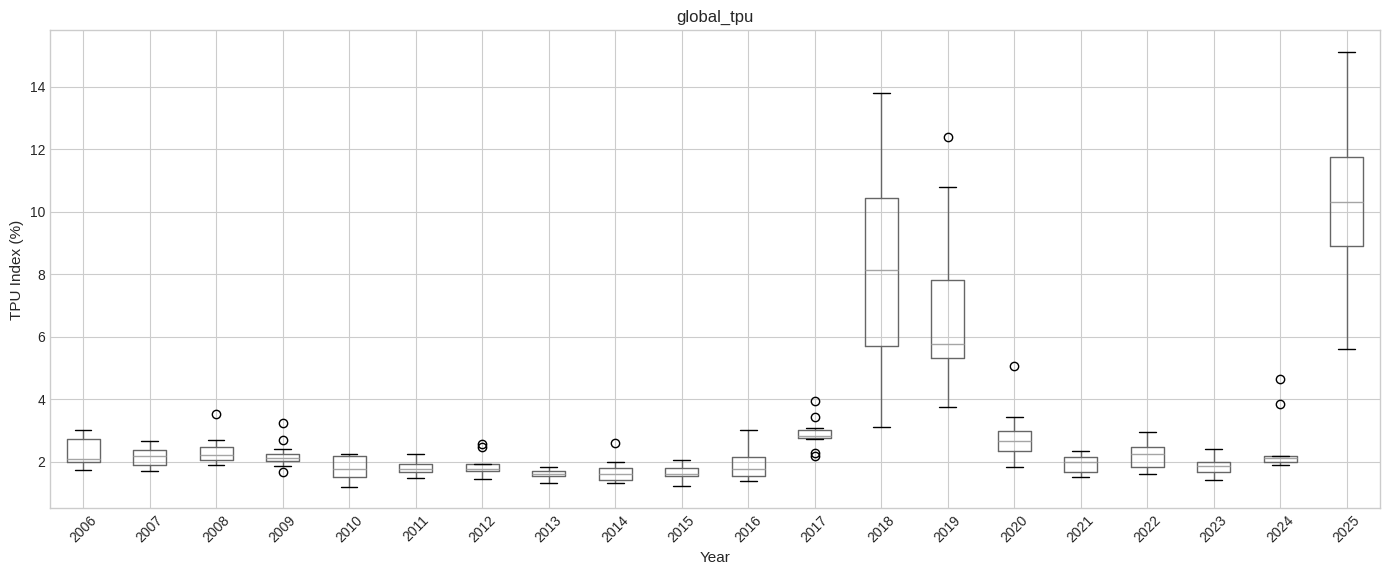

In [31]:
# Box plot: Distribution of monthly TPU by year
print("Chart: Distribution of Monthly TPU by Year")

fig, ax = plt.subplots(figsize=(14, 6))
global_simple_sorted.boxplot(column='global_tpu', by='year', ax=ax)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('TPU Index (%)', fontsize=11)
plt.suptitle('')  # Remove default title
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}tpu_boxplot_yearly.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3: Major Countries Analysis (G7 + BRICS)

**Goal**: Normalized TPU trends for major economies

In [32]:
# Define country groups
G7_COUNTRIES = ['USA', 'GBR', 'DEU', 'FRA', 'JPN', 'ITA', 'CAN']
# Note: South Africa (ZAF) not included in dataset, using BRIC countries
BRICS_COUNTRIES = ['BRA', 'RUS', 'IND', 'CHN']

G7_NAMES = {'USA': 'United States', 'GBR': 'United Kingdom', 'DEU': 'Germany',
            'FRA': 'France', 'JPN': 'Japan', 'ITA': 'Italy', 'CAN': 'Canada'}
BRICS_NAMES = {'BRA': 'Brazil', 'RUS': 'Russia', 'IND': 'India', 'CHN': 'China'}

def get_country_data(df, countries):
    """Get country data dict using pre-computed normalized_TPUD_index from CSV."""
    result = {}
    for country in countries:
        country_data = df[df['iso'] == country].sort_values('pub_period')
        if len(country_data) > 0 and country_data['normalized_TPUD_index'].notna().any():
            result[country] = country_data
    return result

### 3.1 G7 Countries TPU Trends

Chart: G7 Countries - Normalized TPU Trends (Base Period = 100)


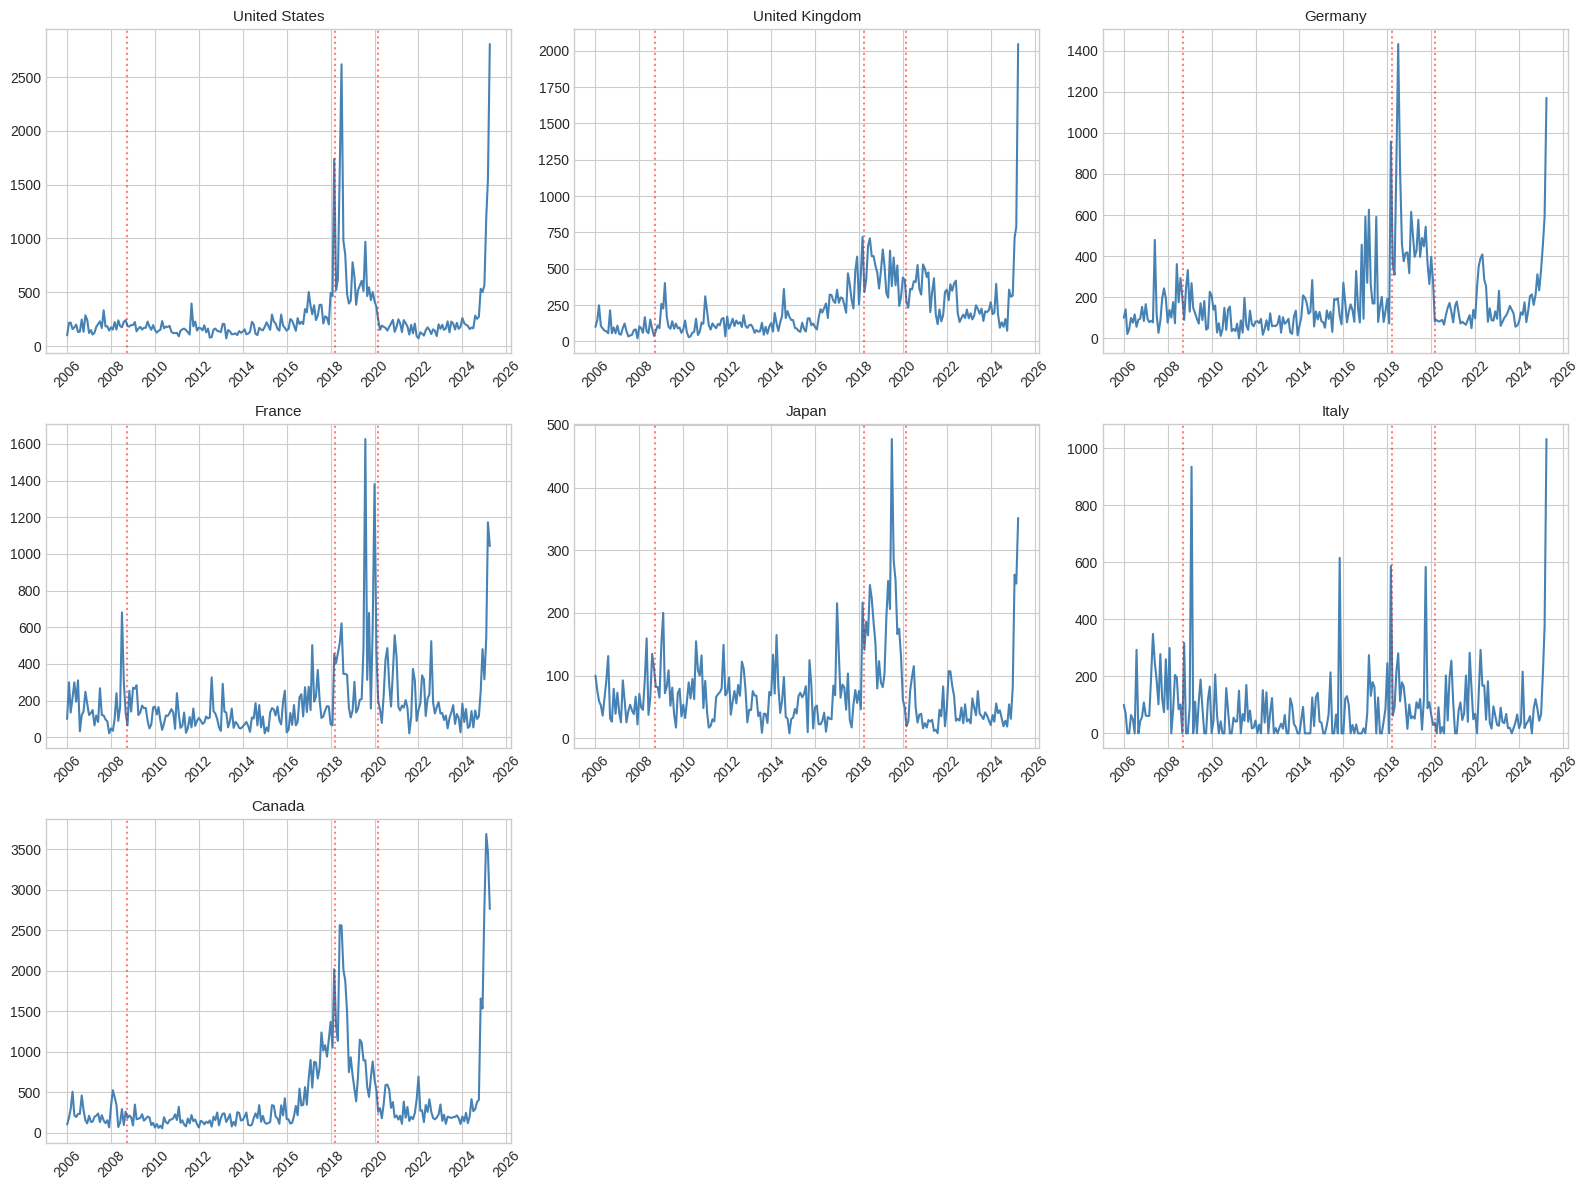

In [33]:
# Get G7 country data
g7_data = get_country_data(df_country, G7_COUNTRIES)

# Panel of individual country plots with event annotations
print("Chart: G7 Countries - Normalized TPU Trends (Base Period = 100)")

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

events = [
    ('2008-09-15', 'Lehman'),
    ('2018-03-22', 'Trade War'),
    ('2020-03-01', 'COVID'),
]

for i, country in enumerate(G7_COUNTRIES):
    ax = axes[i]
    if country in g7_data:
        data = g7_data[country]
        ax.plot(data['pub_period'], data['normalized_TPUD_index'], linewidth=1.5, color='steelblue')
        
        # Add events
        for date, label in events:
            ax.axvline(pd.Timestamp(date), color='red', linestyle=':', alpha=0.5)
    
    ax.set_title(G7_NAMES[country], fontsize=11)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)

# Hide empty subplots
for i in range(len(G7_COUNTRIES), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}g7_individual_panels.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 BRICS Countries TPU Trends

Chart: BRICS Countries - Normalized TPU Trends (Base Period = 100)


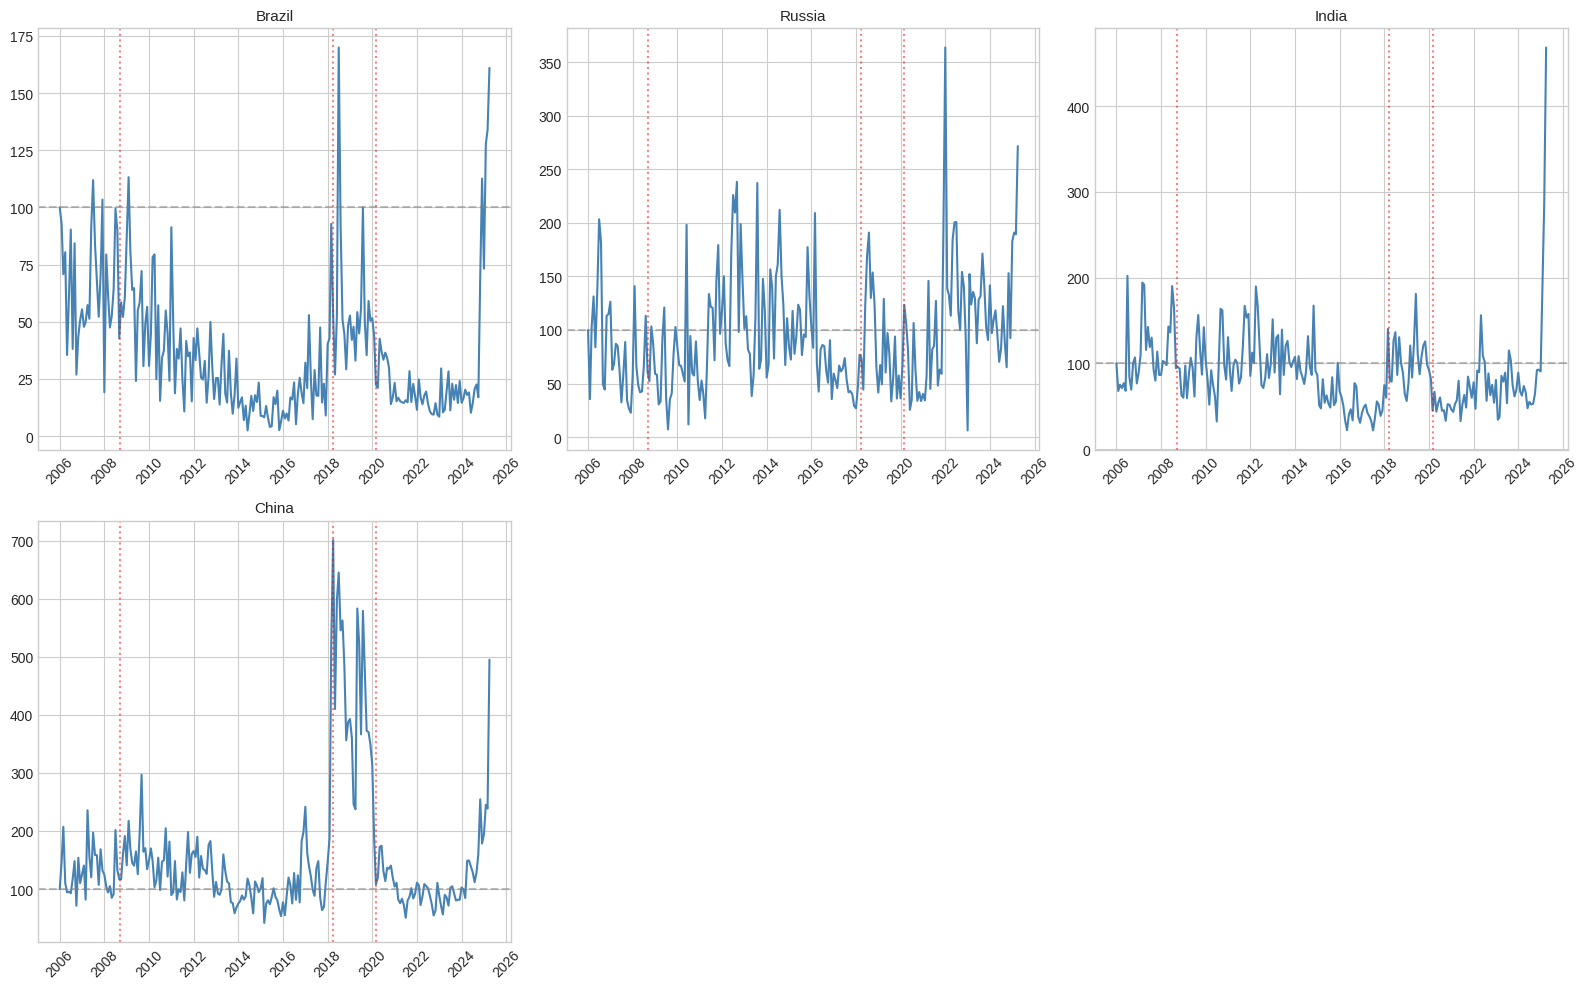

In [34]:
# Get BRICS country data (using pre-computed normalized_TPUD_index)
brics_data = get_country_data(df_country, BRICS_COUNTRIES)

# Panel of individual country plots with event annotations
print("Chart: BRICS Countries - Normalized TPU Trends (Base Period = 100)")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

events = [
    ('2008-09-15', 'Lehman'),
    ('2018-03-22', 'Trade War'),
    ('2020-03-01', 'COVID'),
]

for i, country in enumerate(BRICS_COUNTRIES):
    ax = axes[i]
    if country in brics_data:
        data = brics_data[country]
        ax.plot(data['pub_period'], data['normalized_TPUD_index'], linewidth=1.5, color='steelblue')
        
        # Add events
        for date, label in events:
            ax.axvline(pd.Timestamp(date), color='red', linestyle=':', alpha=0.5)
    
    ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(BRICS_NAMES[country], fontsize=11)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)

# Hide empty subplots
for i in range(len(BRICS_COUNTRIES), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}brics_individual_panels.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 G7 vs BRICS Comparison

Chart: G7 vs BRICS Comparison (Raw TPU Index and Normalized TPU Index)


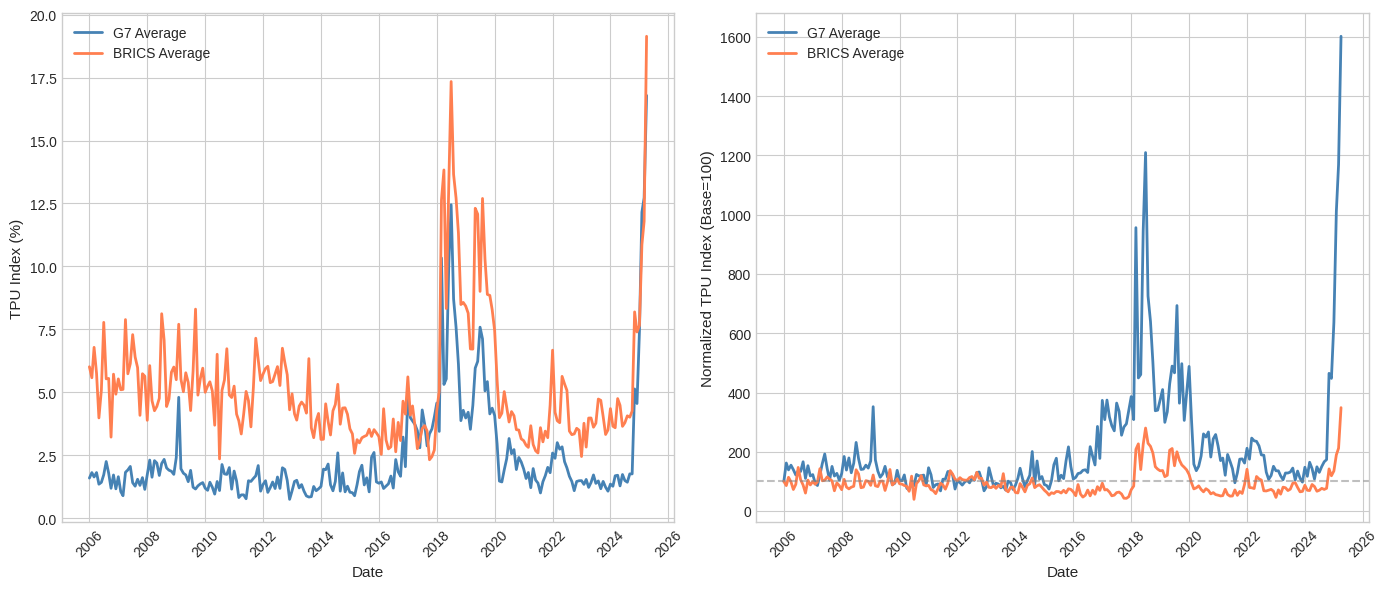

In [35]:
# Calculate group averages using pre-computed normalized values
g7_df = df_country[df_country['iso'].isin(G7_COUNTRIES)]
brics_df = df_country[df_country['iso'].isin(BRICS_COUNTRIES)]

# Raw TPU index averages
g7_avg = g7_df.groupby('pub_period')['TPUD_index'].mean().reset_index(name='G7_avg')
brics_avg = brics_df.groupby('pub_period')['TPUD_index'].mean().reset_index(name='BRICS_avg')

# Normalized TPU index averages (using pre-computed values)
g7_norm_avg = g7_df.groupby('pub_period')['normalized_TPUD_index'].mean().reset_index(name='G7_normalized')
brics_norm_avg = brics_df.groupby('pub_period')['normalized_TPUD_index'].mean().reset_index(name='BRICS_normalized')

# Merge all
comparison = g7_avg.merge(brics_avg, on='pub_period', how='outer')
comparison = comparison.merge(g7_norm_avg, on='pub_period', how='outer')
comparison = comparison.merge(brics_norm_avg, on='pub_period', how='outer')
comparison = comparison.sort_values('pub_period')

print("Chart: G7 vs BRICS Comparison (Raw TPU Index and Normalized TPU Index)")

# Plot overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw values
axes[0].plot(comparison['pub_period'], comparison['G7_avg'], 
             label='G7 Average', linewidth=2, color='steelblue')
axes[0].plot(comparison['pub_period'], comparison['BRICS_avg'], 
             label='BRICS Average', linewidth=2, color='coral')
axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('TPU Index (%)', fontsize=11)
axes[0].legend()
axes[0].xaxis.set_major_locator(mdates.YearLocator(2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Normalized (using pre-computed values)
axes[1].plot(comparison['pub_period'], comparison['G7_normalized'], 
             label='G7 Average', linewidth=2, color='steelblue')
axes[1].plot(comparison['pub_period'], comparison['BRICS_normalized'], 
             label='BRICS Average', linewidth=2, color='coral')
axes[1].axhline(y=100, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Normalized TPU Index (Base=100)', fontsize=11)
axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}g7_vs_brics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4: Regional Aggregates

**Goal**: Compare TPU across regions and income groups

### 4.1 By UN Major Region

Chart: TPU by UN Region (Simple Average and GDP-Weighted Average)


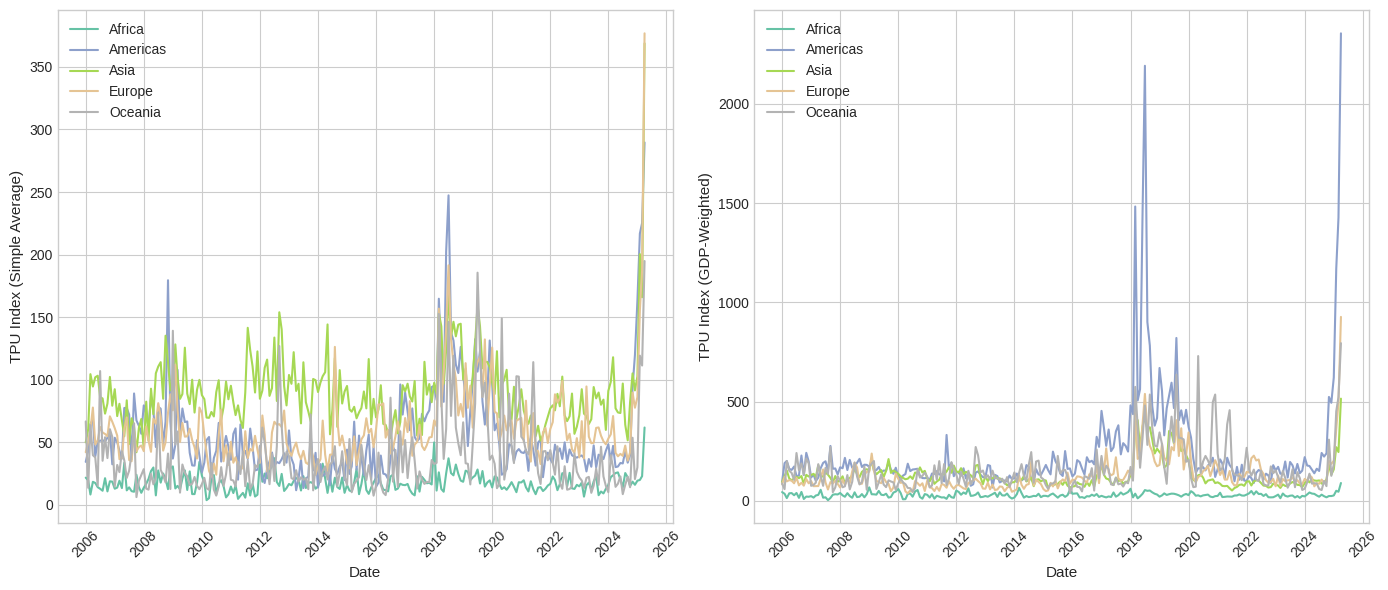

In [36]:
# Multi-line plot: 5 regions
print("Chart: TPU by UN Region (Simple Average and GDP-Weighted Average)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
regions = df_region['un_major_region'].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(regions)))

# Simple average
for i, region in enumerate(regions):
    region_data = df_region[df_region['un_major_region'] == region].sort_values('pub_period')
    axes[0].plot(region_data['pub_period'], region_data['simple_avg'], 
                 label=region, linewidth=1.5, color=colors[i])

axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('TPU Index (Simple Average)', fontsize=11)
axes[0].legend(loc='upper left')

# GDP-weighted
for i, region in enumerate(regions):
    region_data = df_region[df_region['un_major_region'] == region].sort_values('pub_period')
    axes[1].plot(region_data['pub_period'], region_data['gdp_weighted_avg'], 
                 label=region, linewidth=1.5, color=colors[i])

axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('TPU Index (GDP-Weighted)', fontsize=11)
axes[1].legend(loc='upper left')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}un_region_tpu.png', dpi=150, bbox_inches='tight')
plt.show()

Chart: TPU by UN Region - Individual Trends


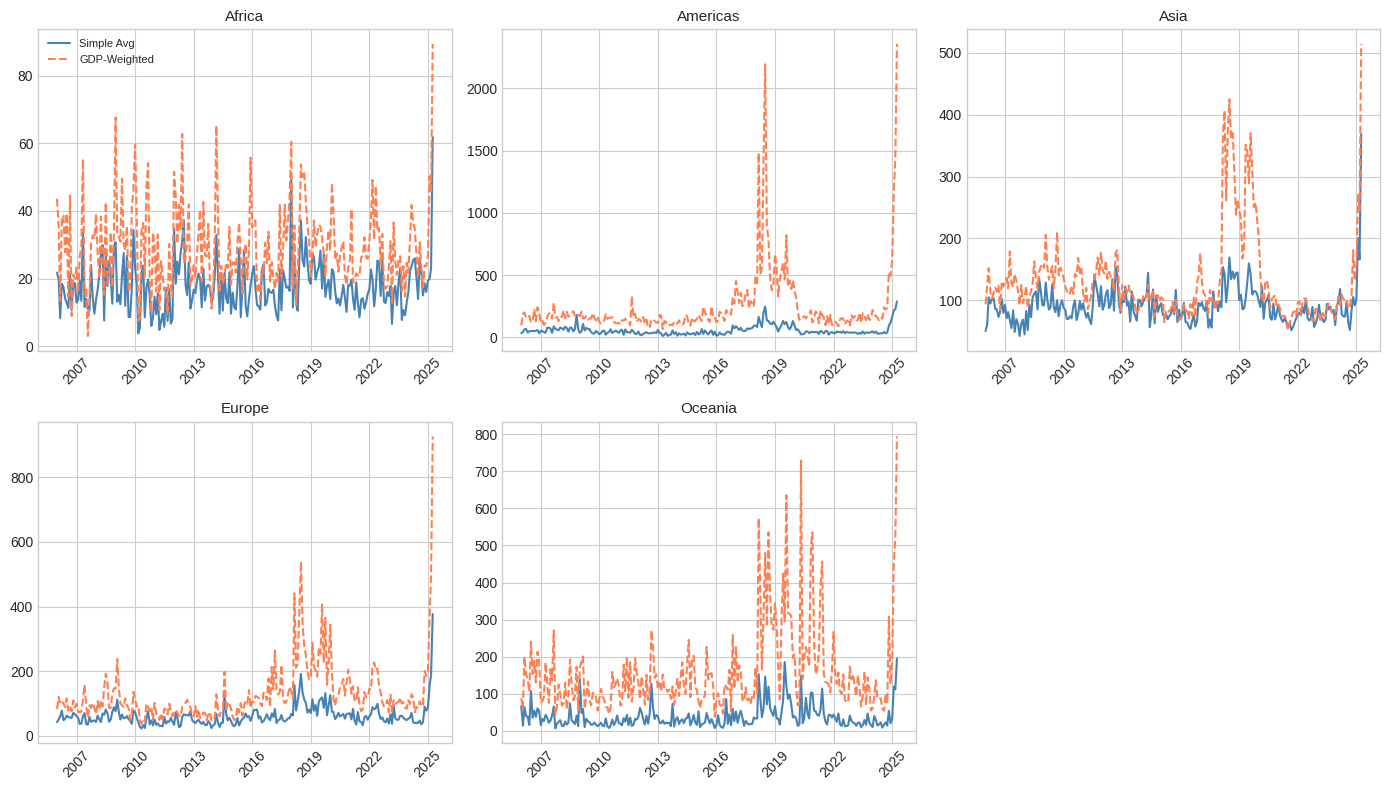

In [37]:
# Faceted small multiples
print("Chart: TPU by UN Region - Individual Trends")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, region in enumerate(regions):
    ax = axes[i]
    region_data = df_region[df_region['un_major_region'] == region].sort_values('pub_period')
    
    ax.plot(region_data['pub_period'], region_data['simple_avg'], 
            label='Simple Avg', linewidth=1.5, color='steelblue')
    ax.plot(region_data['pub_period'], region_data['gdp_weighted_avg'], 
            label='GDP-Weighted', linewidth=1.5, color='coral', linestyle='--')
    
    ax.set_title(region, fontsize=11)
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)
    if i == 0:
        ax.legend(loc='upper left', fontsize=8)

# Hide empty subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}un_region_panels.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 By Income Group

Chart: TPU by Income Group (Simple Average and GDP-Weighted Average)


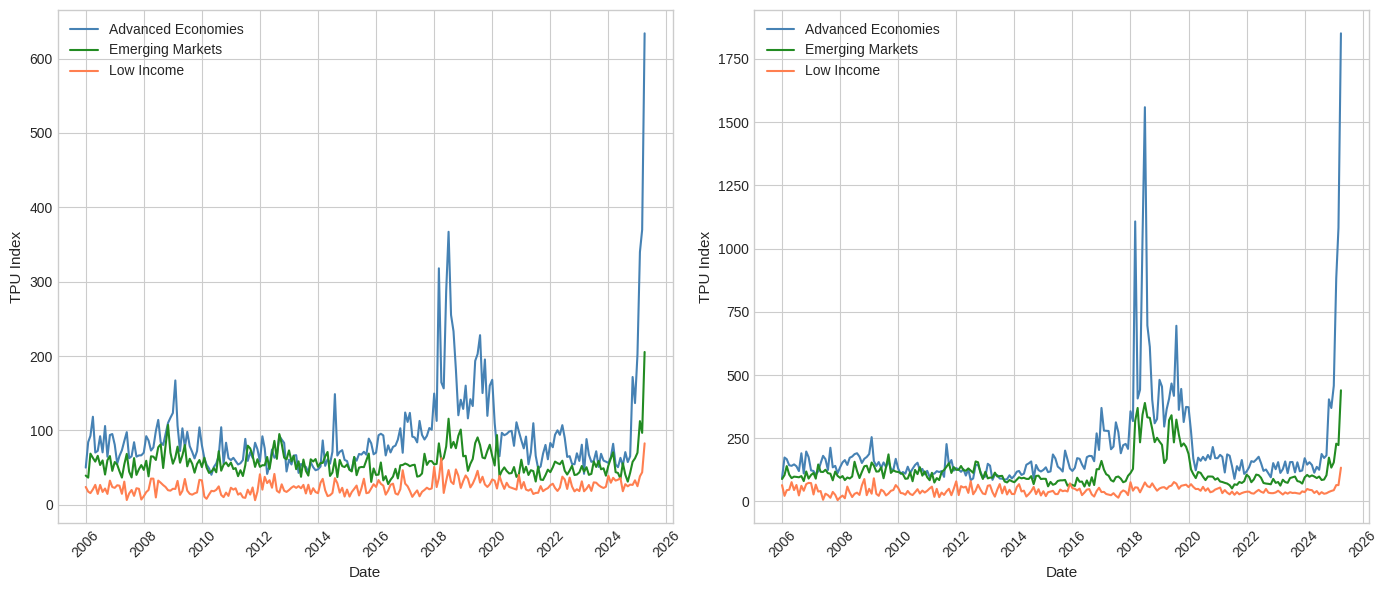

In [38]:
# Line plot: LIC vs EM vs AE
income_labels = {'LIC': 'Low Income', 'EM': 'Emerging Markets', 
                 'AE': 'Advanced Economies', 'AM': 'Advanced Markets'}
income_colors = {'LIC': 'coral', 'EM': 'forestgreen', 'AE': 'steelblue', 'AM': 'purple'}

print("Chart: TPU by Income Group (Simple Average and GDP-Weighted Average)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for income in df_income['income_group'].unique():
    income_data = df_income[df_income['income_group'] == income].sort_values('pub_period')
    label = income_labels.get(income, income)
    color = income_colors.get(income, 'gray')
    
    axes[0].plot(income_data['pub_period'], income_data['simple_avg'], 
                 label=label, linewidth=1.5, color=color)
    axes[1].plot(income_data['pub_period'], income_data['gdp_weighted_avg'], 
                 label=label, linewidth=1.5, color=color)

for ax in axes:
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('TPU Index', fontsize=11)
    ax.legend(loc='upper left')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}income_group_tpu.png', dpi=150, bbox_inches='tight')
plt.show()

Chart: TPU Gap - Advanced Economies vs Emerging Markets


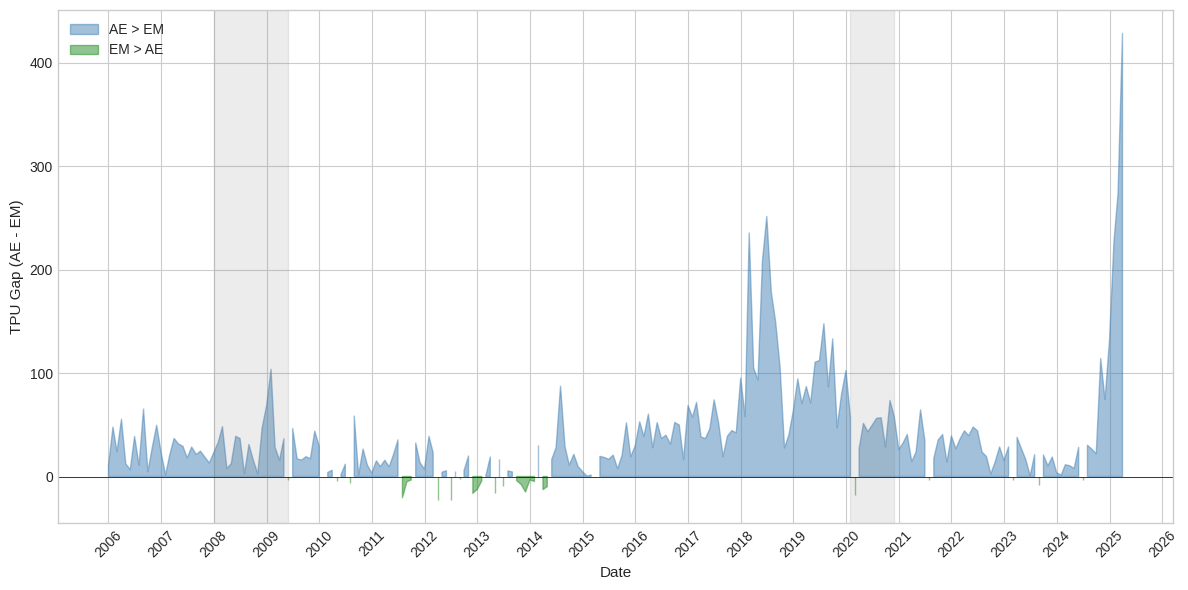

In [39]:
# Gap analysis: How do income groups diverge during crises?
# Create pivot table
income_pivot = df_income.pivot_table(values='simple_avg', 
                                      index='pub_period', 
                                      columns='income_group')

# Calculate gap between AE and EM
if 'AE' in income_pivot.columns and 'EM' in income_pivot.columns:
    income_pivot['AE_EM_gap'] = income_pivot['AE'] - income_pivot['EM']
    
    print("Chart: TPU Gap - Advanced Economies vs Emerging Markets")
    
    fig, ax = plt.subplots(figsize=SINGLE_FIG_SIZE)
    ax.fill_between(income_pivot.index, 0, income_pivot['AE_EM_gap'],
                    where=income_pivot['AE_EM_gap'] >= 0, alpha=0.5, 
                    color='steelblue', label='AE > EM')
    ax.fill_between(income_pivot.index, 0, income_pivot['AE_EM_gap'],
                    where=income_pivot['AE_EM_gap'] < 0, alpha=0.5, 
                    color='forestgreen', label='EM > AE')
    
    # Highlight crisis periods
    ax.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2009-06-01'), 
               alpha=0.15, color='gray')
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-12-01'), 
               alpha=0.15, color='gray')
    
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('TPU Gap (AE - EM)', fontsize=11)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}income_group_gap.png', dpi=150, bbox_inches='tight')
    plt.show()

### 4.3 By IMF Department

Chart: TPU by IMF Regional Department (Simple Average and GDP-Weighted Average)


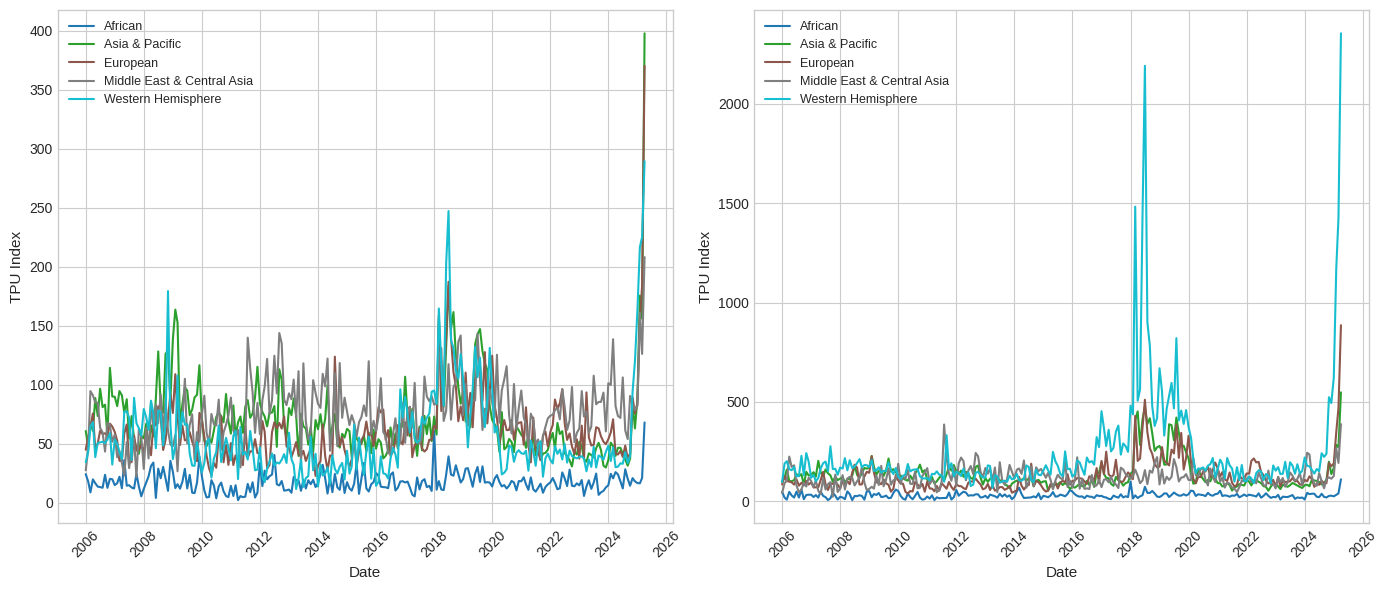

In [40]:
# Line plot: EUR, WHD, APD, MCD, AFR
imf_labels = {'EUR': 'European', 'WHD': 'Western Hemisphere', 
              'APD': 'Asia & Pacific', 'MCD': 'Middle East & Central Asia', 
              'AFR': 'African'}

print("Chart: TPU by IMF Regional Department (Simple Average and GDP-Weighted Average)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(df_imf['imf_dept_code'].unique())))

for i, dept in enumerate(df_imf['imf_dept_code'].unique()):
    dept_data = df_imf[df_imf['imf_dept_code'] == dept].sort_values('pub_period')
    label = imf_labels.get(dept, dept)
    
    axes[0].plot(dept_data['pub_period'], dept_data['simple_avg'], 
                 label=label, linewidth=1.5, color=colors[i])
    axes[1].plot(dept_data['pub_period'], dept_data['gdp_weighted_avg'], 
                 label=label, linewidth=1.5, color=colors[i])

for ax in axes:
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('TPU Index', fontsize=11)
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}imf_dept_tpu.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Regional Correlation Matrix

Chart: TPU Correlation Matrix - UN Regions


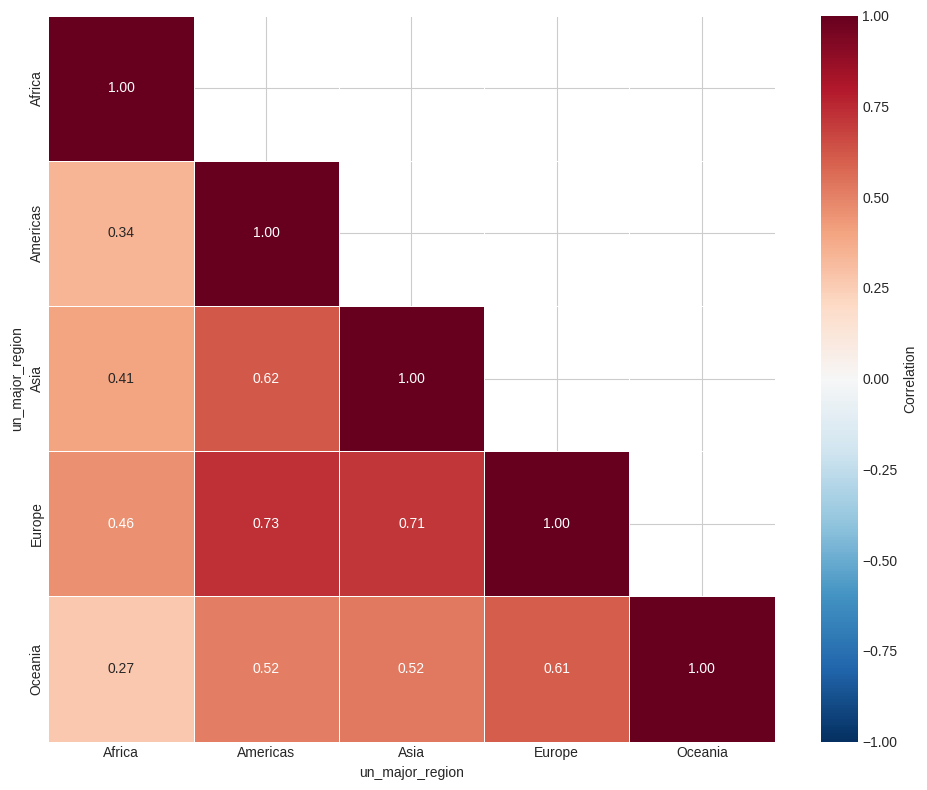


Regional TPU Correlation Matrix:
un_major_region  Africa  Americas   Asia  Europe  Oceania
un_major_region                                          
Africa            1.000     0.341  0.406   0.461    0.268
Americas          0.341     1.000  0.621   0.729    0.516
Asia              0.406     0.621  1.000   0.713    0.524
Europe            0.461     0.729  0.713   1.000    0.607
Oceania           0.268     0.516  0.524   0.607    1.000


In [41]:
# Create correlation matrix for UN regions
region_pivot = df_region.pivot_table(values='simple_avg', 
                                      index='pub_period', 
                                      columns='un_major_region')
region_corr = region_pivot.corr()

print("Chart: TPU Correlation Matrix - UN Regions")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(region_corr, dtype=bool), k=1)
sns.heatmap(region_corr, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlation'})
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}region_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRegional TPU Correlation Matrix:")
print(region_corr.round(3).to_string())

Chart: TPU Correlation Matrix - IMF Departments


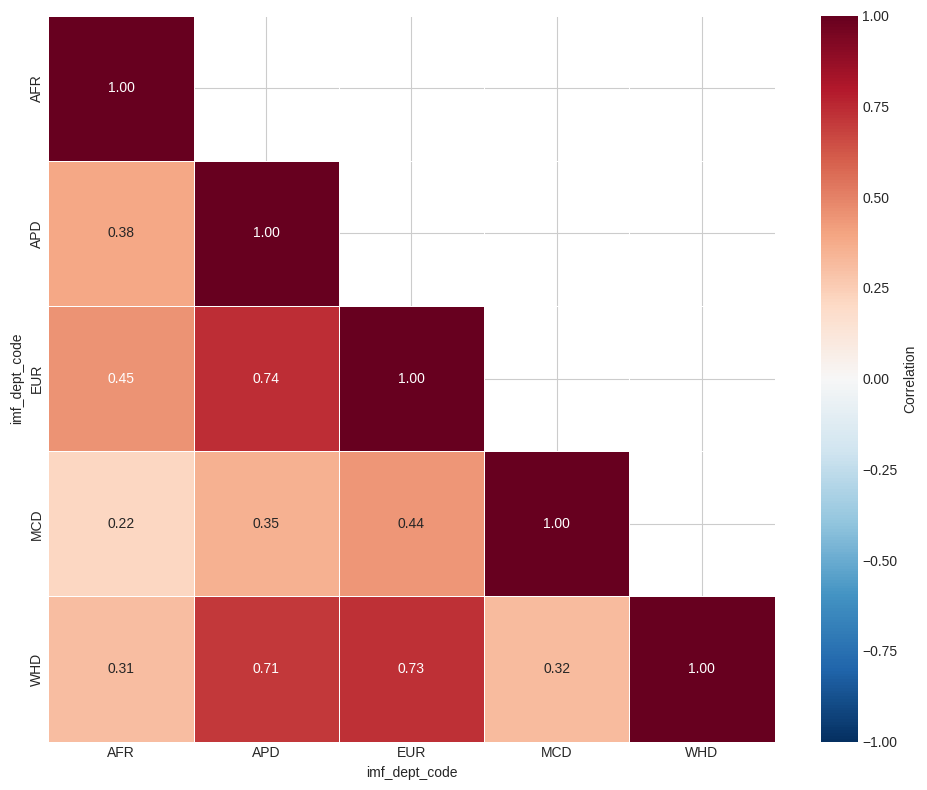

In [42]:
# IMF department correlation
imf_pivot = df_imf.pivot_table(values='simple_avg', 
                                index='pub_period', 
                                columns='imf_dept_code')
imf_corr = imf_pivot.corr()

print("Chart: TPU Correlation Matrix - IMF Departments")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(imf_corr, dtype=bool), k=1)
sns.heatmap(imf_corr, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlation'})
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}imf_dept_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5: Summary Dashboard

**Goal**: Quick reference with key metrics

In [43]:
# Summary statistics table
latest_period = df_country['pub_period'].max()
one_year_ago = latest_period - pd.DateOffset(years=1)

# Global metrics
global_current = global_simple[global_simple['pub_period'] == latest_period]['global_tpu'].values[0]
global_1yr_ago = global_simple[global_simple['pub_period'] == one_year_ago]['global_tpu'].values[0]
global_historical_avg = global_simple['global_tpu'].mean()
global_1yr_change = global_current - global_1yr_ago

print("="*70)
print("TPU SUMMARY STATISTICS")
print("="*70)
print(f"\nData as of: {latest_period.strftime('%Y-%m')}")
print(f"\nGlobal TPU Index:")
print(f"  Current Value:         {global_current:.2f}%")
print(f"  1-Year Change:         {'+' if global_1yr_change > 0 else ''}{global_1yr_change:.2f}%")
print(f"  Historical Average:    {global_historical_avg:.2f}%")

TPU SUMMARY STATISTICS

Data as of: 2025-04

Global TPU Index:
  Current Value:         15.12%
  1-Year Change:         +12.98%
  Historical Average:    2.78%


In [44]:
# Regional summary
print("\n" + "="*70)
print("REGIONAL SUMMARY (Current Period)")
print("="*70)

regional_summary = df_region[df_region['pub_period'] == latest_period][['un_major_region', 'simple_avg', 'gdp_weighted_avg']]
regional_summary.columns = ['Region', 'Simple Avg', 'GDP-Weighted']
print(regional_summary.to_string(index=False))


REGIONAL SUMMARY (Current Period)
  Region  Simple Avg  GDP-Weighted
  Africa   61.834000     89.392946
Americas  289.618750   2355.688629
    Asia  368.804545    514.586463
  Europe  376.842500    926.620272
 Oceania  194.862500    794.173738


In [45]:
# Income group summary
print("\n" + "="*70)
print("INCOME GROUP SUMMARY (Current Period)")
print("="*70)

income_summary = df_income[df_income['pub_period'] == latest_period][['income_group', 'simple_avg', 'gdp_weighted_avg']]
income_summary.columns = ['Income Group', 'Simple Avg', 'GDP-Weighted']
income_summary['Income Group'] = income_summary['Income Group'].map(
    {'LIC': 'Low Income', 'EM': 'Emerging Markets', 'AE': 'Advanced Economies', 'AM': 'Advanced Markets'}
)
print(income_summary.to_string(index=False))


INCOME GROUP SUMMARY (Current Period)
      Income Group  Simple Avg  GDP-Weighted
Advanced Economies  634.027027   1851.057226
  Emerging Markets  205.474118    439.542510
        Low Income   82.600000    133.674396


Chart: TPU Summary Dashboard


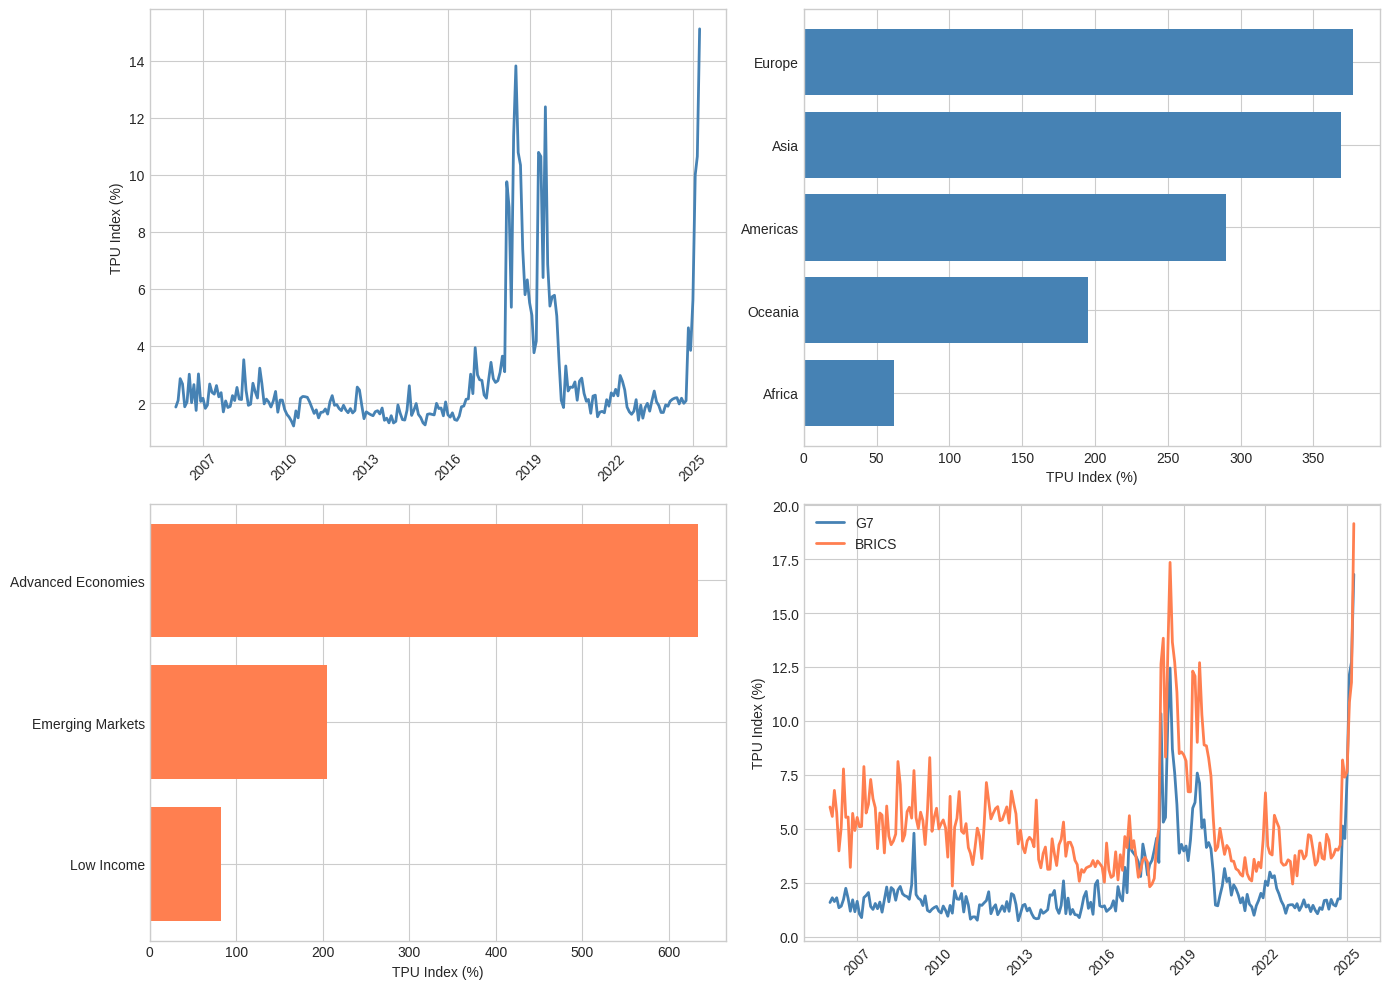


All figures saved to: /data/home/xiong/data/Fund/Factiva_News/results/merged_results/figures/


In [46]:
# Final summary visualization
print("Chart: TPU Summary Dashboard")

fig, axes = plt.subplots(2, 2, figsize=MULTI_FIG_SIZE)

# 1. Global TPU trend
axes[0, 0].plot(global_simple['pub_period'], global_simple['global_tpu'], 
                linewidth=2, color='steelblue')
axes[0, 0].set_ylabel('TPU Index (%)')

# 2. Regional comparison (latest period)
regional_bar = df_region[df_region['pub_period'] == latest_period].sort_values('simple_avg', ascending=True)
axes[0, 1].barh(regional_bar['un_major_region'], regional_bar['simple_avg'], color='steelblue')
axes[0, 1].set_xlabel('TPU Index (%)')

# 3. Income group comparison
income_bar = df_income[df_income['pub_period'] == latest_period].sort_values('simple_avg', ascending=True)
income_bar['income_label'] = income_bar['income_group'].map(income_labels)
axes[1, 0].barh(income_bar['income_label'], income_bar['simple_avg'], color='coral')
axes[1, 0].set_xlabel('TPU Index (%)')

# 4. G7 vs BRICS
axes[1, 1].plot(comparison['pub_period'], comparison['G7_avg'], 
                label='G7', linewidth=2, color='steelblue')
axes[1, 1].plot(comparison['pub_period'], comparison['BRICS_avg'], 
                label='BRICS', linewidth=2, color='coral')
axes[1, 1].set_ylabel('TPU Index (%)')
axes[1, 1].legend()

for ax in axes.flatten():
    if hasattr(ax, 'xaxis') and ax.get_xlabel() == '':
        ax.xaxis.set_major_locator(mdates.YearLocator(3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAll figures saved to: {OUTPUT_DIR}")

---
## Verification Checklist

- [x] All 5 sections render without errors
- [x] Time series plots show full 2006-2025 range
- [x] Major countries (USA, CHN, DEU) appear correctly in charts
- [x] Regional aggregates match pre-computed CSV values
- [x] Figures are publication-ready quality